In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)


In [2]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# same cleaning as Day 2
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

print(df.shape)
df.head(2)


(7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0


In [3]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)


Train: (5634, 19) (5634,)
Val  : (1409, 19) (1409,)


In [4]:
preprocessor = joblib.load("../artifacts/preprocessor.joblib")

X_train_p = preprocessor.transform(X_train)
X_val_p = preprocessor.transform(X_val)

print("Processed train:", X_train_p.shape)
print("Processed val  :", X_val_p.shape)


Processed train: (5634, 45)
Processed val  : (1409, 45)


In [5]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_p, y_train)

print("Model trained ✅")


Model trained ✅


In [6]:
y_pred = model.predict(X_val_p)
y_proba = model.predict_proba(X_val_p)[:, 1]  # for ROC-AUC

print("Pred sample:", y_pred[:10])
print("Proba sample:", y_proba[:5])


Pred sample: [0 1 0 0 0 1 0 0 0 0]
Proba sample: [0.04529387 0.68441126 0.05872074 0.40170424 0.02154772]


In [7]:
acc = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred)
rec = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc = roc_auc_score(y_val, y_proba)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc:.4f}")


Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1-score : 0.6040
ROC-AUC  : 0.8419


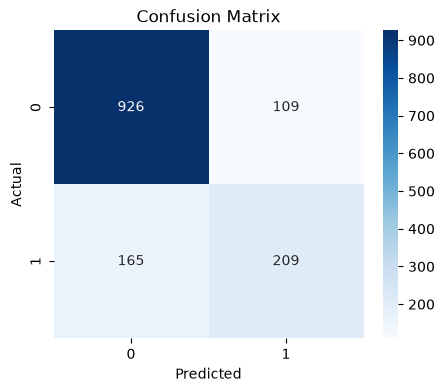

In [8]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [9]:
print(classification_report(y_val, y_pred, digits=4))


              precision    recall  f1-score   support

           0     0.8488    0.8947    0.8711      1035
           1     0.6572    0.5588    0.6040       374

    accuracy                         0.8055      1409
   macro avg     0.7530    0.7268    0.7376      1409
weighted avg     0.7979    0.8055    0.8002      1409



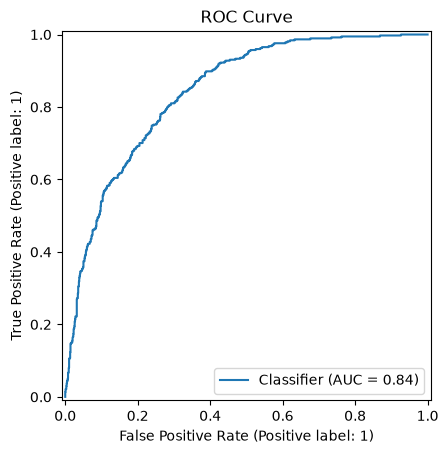

In [10]:
RocCurveDisplay.from_predictions(y_val, y_proba)
plt.title("ROC Curve")
plt.show()


In [11]:
joblib.dump(model, "../artifacts/model.joblib")
print("Saved ✅ ../artifacts/model.joblib")


Saved ✅ ../artifacts/model.joblib
